# WHAT IS THIS NOTEBOOK ABOUT?
* This notebook is about minimizing the energy of bulk generated to 
1. Find 0 K equilibrium geometry and lattice parameter
2. Short NPT run (100 ps) to determine finite-temperature lattice parameter at each target T


### WORKFLOW
> 1. Define Imports, Paths and Parameters
> 2. Check the size and thickness of the input structure (This is important because alloy contain different atoms with different sizes)
> 3. Write a LAMMPS minimization script (to Find the 0 K equilibrium geometry and lattice parameter using CG minimization algorithm)
> 4. Write a SLURM Job script
> 5. Run minimization on HPC
> 6. Parse minimization log to extract lattice parameter vs time
> 7. Cohesive Energy Validation

Extract Finite temperature lattice parameter 


> 8. Write LAMMPS NPT script
> 9. Write SLURM NPT job script
> 10.Parse NPT log to extract lattice parameter vs time
> 11. Plot: a. energy convergence + Lattice parameter equilibration
> 12. Decision Cell. Proceed or rebuild

# 1. Define Imports, Paths and Parameters

### 1a Imports

In [4]:
import numpy as np
import subprocess
import os
import matplotlib.pyplot as plt
import matplotlib
from ase.io import read, write
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

import ase
print(f'ASE version   : {ase.__version__}')
print(f'NumPy version : {np.__version__}')
print(f'Matplotlib version : {matplotlib.__version__}')


ASE version   : 3.27.0
NumPy version : 2.4.3
Matplotlib version : 3.10.8


### 1b and c Define Paths and Parameters
Define

> 1. Lammps executabl path
> 2. Mace_model path
> 3. Base Project directory
> 4. GPU compartible with MACE, LAMMPS and HPC kokkos flags


In [5]:

# ═══════════════════════════════════════════════════════════════
# YOUR SYSTEM PATHS — update these for your HPC cluster
# ═══════════════════════════════════════════════════════════════

# LAMMPS executable (your mliap build)
LAMMPS_CMD   = '/projects/westgroup/akinyemi.az/mace_lammps/lammps/build-mliap/lmp'

# MACE-MP-0b2 model (mliap unified format)
MACE_MODEL   = '/projects/westgroup/akinyemi.az/mace_lammps/models/mace-mp-0b2-medium.model-mliap_lammps.pt'

# Base project directory
BASE_DIR     = '/projects/westgroup/akinyemi.az/mace_lammps/MHI_Nickel'
# ── Kokkos GPU flags (from your production script) ──────────────
# Ref: Trott et al. 2022 [17]
KOKKOS_FLAGS = ['-k', 'on', 'g', '1',
                '-sf', 'kk',
                '-pk', 'kokkos', 'newton', 'on', 'neigh', 'half']

# ── pair_style for mliap unified interface ──────────────────────
# Syntax: pair_style mliap unified <model> 0  [15,16]
PAIR_STYLE       = 'mliap unified'
PAIR_STYLE_SUFFIX = '0'

# ── Atom type mapping (ASE alphabetical — from Notebook 01) ─────
# MUST match pair_coeff element order [15,16]
TYPE_MAP     = {1:'Al', 2:'B', 3:'C', 4:'Cr', 5:'Fe', 6:'Mo', 7:'Ni', 8: 'O'}
# H = type 8 when added in Notebooks 05–11
ELEM_STR     = ' '.join([TYPE_MAP[i] for i in sorted(TYPE_MAP)]) + ' H'
# → 'Al B C Cr Fe Mo Ni H'

# ── SLURM settings (matches your cluster) ───────────────────────
SLURM_CONFIG = {
    'partition'     : 'gpu',
    'ntasks'        : 1,
    'cpus_per_task' : 8,
    'gpu'           : 'a100:1',
    'time'          : '8:00:00',
    'conda_env'     : 'mace-lammps',
    'cuda_version'  : '12.3.0',
    'openmpi_ver'   : '4.1.6',
    'ld_paths'      : [
        '/shared/EL9/explorer/cuda/12.3.0/lib64/stubs',
        '/projects/westgroup/akinyemi.az/mace_lammps/lammps/build-mliap',
        '/home/akinyemi.az/miniforge3/envs/mace-lammps/lib',
    ]
}

# ── File paths ───────────────────────────────────────────────────
#BULK_INPUT   = 'structures/bulk_structures/Ni_supercell.lammps'       # from Notebook 01
BULK_INPUT   = 'structures/bulk_structures/Ni_oxide_supercell.lammps' 
MIN_OUTPUT   = 'structures/02_bulk_energy_minimization/Ni_oxide_minimized.lammps'
MIN_LOG      = 'results/02_bulk_energy_minimization/Ni_oxide_minimization.log'
NPT_LOG      = 'results/02_bulk_energy_minimization/Ni_oxide_npt_lattice.log'
NPT_DUMP     = 'results/02_bulk_energy_minimization/Ni_oxide_npt_box.txt'

# ── Simulation parameters ────────────────────────────────────────
TARGET_T     = 300            # K 
TIMESTEP     = 0.0005         # ps = 0.5 fs 
NPT_STEPS    = 200000         # steps × 0.5 fs = 100 ps NPT run

# ── Minimization settings  ───────
ETOL         = 0
FTOL         = 1e-8
MAXITER      = 100000
MAXEVAL      = 1000000

# ── Validation thresholds ──────────────────────────────────────── 
# Cohensive Energy Handbook: https://www.knowledgedoor.com/2/elements_handbook/cohesive_energy.html
# Al = 4.25 eV/atom 
# B = 5.81 eV/atom
# C = 7.37 ev/atom
# Cr = 4.10 ev/atom
# Fe = 4.28 ev/atom
# Mo = 6.82 eV/atom
# Ni =  4.44 eV/atom
# O = 2.60 ev/atom

ECOH_MIN     = 4.0    # eV/atom 
ECOH_MAX     = 7.5    # eV/atom  
ALAT_TOL     = 0.005  # 0.5% lattice parameter tolerance
A0_REF       = 4.19  # Å — reference from Notebook 01 

# Create directories
for d in ['results/02_bulk_energy_minimization', 'lammps_scripts/02_bulk_energy_minimization', 'slurm_scripts/02_bulk_energy_minimization', 'structures/02_bulk_energy_minimization']:
    os.makedirs(d, exist_ok=True)

# Verify input
if not os.path.exists(BULK_INPUT):
    raise FileNotFoundError(f'{BULK_INPUT} not found. Run Notebook 01 first.')

print(f'\nInput file     : {BULK_INPUT} ✓')
print(f'LAMMPS         : {LAMMPS_CMD}')
print(f'Model          : {MACE_MODEL}')
print(f'pair_coeff     : {ELEM_STR}')
print(f'Kokkos flags   : {", ".join(KOKKOS_FLAGS)}')
print(f'Target T       : {TARGET_T} K')
print(f'Timestep       : {TIMESTEP*1000:.1f} fs')
print(f'NPT length     : {NPT_STEPS * TIMESTEP * 1000:.0f} ps')


Input file     : structures/bulk_structures/Ni_oxide_supercell.lammps ✓
LAMMPS         : /projects/westgroup/akinyemi.az/mace_lammps/lammps/build-mliap/lmp
Model          : /projects/westgroup/akinyemi.az/mace_lammps/models/mace-mp-0b2-medium.model-mliap_lammps.pt
pair_coeff     : Al B C Cr Fe Mo Ni O H
Kokkos flags   : -k, on, g, 1, -sf, kk, -pk, kokkos, newton, on, neigh, half
Target T       : 300 K
Timestep       : 0.5 fs
NPT length     : 100000 ps


# 2. Input structure size and thickness analysis
> 1. Load the structure
> 2. Estimate lattice parameter

    - Divide the mean length of the structure by supercell size e.g x,y,z divide by 5x5x5

> 3. Layer Analysis: 

    - Tall all Z-coordinates of every atom, round to 2 decimal places to group atoms of the same planes,
    - then count unique values (for 5x5x5 its 10 layers)
    - then find the average spacing between adjacent planes

> 4. Minimimum MLIP image convection: cutoff radius (MACE ~6A)
> 5. H interstitial site count: octahedral = 1/metal atom and tetra = 2/metal atom

In [6]:
# ─────────────────────────────────────────────────────────────
# SIZE & THICKNESS ANALYSIS — Notebook 02
# Refs: minimum image convention [2,3]; MACE cutoff [15]
# ─────────────────────────────────────────────────────────────

atoms = read(BULK_INPUT, format='lammps-data')
L     = atoms.cell.lengths()
pos   = atoms.get_positions()
N     = len(atoms)
comp  = Counter(atoms.get_chemical_symbols())
vol   = atoms.get_volume()

# Estimated a0 from box size (5x5x5 supercell)
supercell_size = 5.0
A0_EST   = np.mean(L) / supercell_size


# Layer analysis: count unique z-coordinate planes
z_vals    = np.sort(np.unique(np.round(pos[:,2], decimals=2)))
n_layers  = len(z_vals)
layer_sp  = np.mean(np.diff(z_vals)) if len(z_vals) > 1 else 0

# MACE cutoff and minimum image check [15]
MACE_RCUT = 6.0   # Å — conservative estimate for MACE-MP-0b2 [15]
MIC_ok    = all(l > 2 * MACE_RCUT for l in L)

# H interstitial sites [10 from Nb01]
n_oct = N       # 1 Oct site per metal atom in FCC
n_tet = 2 * N   # 2 Tet sites per metal atom in FCC

print('=' * 62)
print('  SIZE & THICKNESS ANALYSIS')
print('  Notebook 02 — Bulk supercell (5x5x5 FCC)')
print('=' * 62)
print(f'  Total atoms            : {N}')
print(f'  Box a (Å)              : {L[0]:.4f}')
print(f'  Box b (Å)              : {L[1]:.4f}')
print(f'  Box c (Å)              : {L[2]:.4f}')
print(f'  Volume (Å³)            : {vol:.2f}')
print(f'  Vol/atom (Å³)          : {vol/N:.4f}')
print()
print(f'  Estimated a₀           : {A0_EST:.4f} Å   (box/5)')
print(f'  Distinct z-layers      : {n_layers}')
print(f'  Mean layer spacing     : {layer_sp:.4f} Å')
print()
print(f'  MACE-MP-0b2 cutoff     : {MACE_RCUT:.1f} Å  [15]')
print(f'  Min image: L > 2×rcut  = {2*MACE_RCUT:.1f} Å  [2,3]')
for ax, l in zip(['a','b','c'], L):
    ok = '✓' if l > 2*MACE_RCUT else '✗ TOO SMALL — expand supercell'
    print(f'    {ax} = {l:.3f} Å  {ok}')
print()
print(f'  H interstitial sites available (future notebooks):')
print(f'    Octahedral : {n_oct}  (1 per metal atom, preferred in FCC Ni [10])')
print(f'    Tetrahedral: {n_tet}  (2 per metal atom, higher energy [10])')
print()
print('  Adequacy for Notebook 02:')
rows = [
    ('CG minimization (no size req.)',       True),
    (f'NPT lattice parameter (MIC: {MIC_ok})', MIC_ok),
    ('Cohesive energy (no size req.)',        True),
]
for label, ok in rows:
    print(f'    {"✓" if ok else "✗"} {label}')
if not MIC_ok:
    print('\n  ⚠ Box smaller than 2×rcut — consider higher supercell for NPT')
else:
    print('\n  ✓ All size requirements satisfied')
print('=' * 62)

  SIZE & THICKNESS ANALYSIS
  Notebook 02 — Bulk supercell (5x5x5 FCC)
  Total atoms            : 1000
  Box a (Å)              : 20.9500
  Box b (Å)              : 20.9500
  Box c (Å)              : 20.9500
  Volume (Å³)            : 9195.01
  Vol/atom (Å³)          : 9.1950

  Estimated a₀           : 4.1900 Å   (box/5)
  Distinct z-layers      : 10
  Mean layer spacing     : 2.0956 Å

  MACE-MP-0b2 cutoff     : 6.0 Å  [15]
  Min image: L > 2×rcut  = 12.0 Å  [2,3]
    a = 20.950 Å  ✓
    b = 20.950 Å  ✓
    c = 20.950 Å  ✓

  H interstitial sites available (future notebooks):
    Octahedral : 1000  (1 per metal atom, preferred in FCC Ni [10])
    Tetrahedral: 2000  (2 per metal atom, higher energy [10])

  Adequacy for Notebook 02:
    ✓ CG minimization (no size req.)
    ✓ NPT lattice parameter (MIC: True)
    ✓ Cohesive energy (no size req.)

  ✓ All size requirements satisfied


In [7]:
np.mean(L)

np.float64(20.95)

In [8]:
# ─────────────────────────────────────────────────────────────
# SIZE & THICKNESS ANALYSIS — Notebook 02
# Refs: minimum image convention [2,3]; MACE cutoff [15]
# ─────────────────────────────────────────────────────────────

atoms = read(BULK_INPUT, format='lammps-data')
L     = atoms.cell.lengths()
pos   = atoms.get_positions()
N     = len(atoms)
comp  = Counter(atoms.get_chemical_symbols())
vol   = atoms.get_volume()

# Estimated a0 from box size (5x5x5 supercell)
supercell_size = 5.0
A0_EST   = np.mean(L) / supercell_size


# Layer analysis: count unique z-coordinate planes
z_vals    = np.sort(np.unique(np.round(pos[:,2], decimals=2)))
n_layers  = len(z_vals)
layer_sp  = np.mean(np.diff(z_vals)) if len(z_vals) > 1 else 0

# MACE cutoff and minimum image check [15]
MACE_RCUT = 6.0   # Å — conservative estimate for MACE-MP-0b2 [15]
MIC_ok    = all(l > 2 * MACE_RCUT for l in L)

# H interstitial sites [10 from Nb01]
n_oct = N       # 1 Oct site per metal atom in FCC
n_tet = 2 * N   # 2 Tet sites per metal atom in FCC

print('=' * 62)
print('  SIZE & THICKNESS ANALYSIS')
print('  Notebook 02 — Bulk supercell (5x5x5 FCC)')
print('=' * 62)
print(f'  Total atoms            : {N}')
print(f'  Box a (Å)              : {L[0]:.4f}')
print(f'  Box b (Å)              : {L[1]:.4f}')
print(f'  Box c (Å)              : {L[2]:.4f}')
print(f'  Volume (Å³)            : {vol:.2f}')
print(f'  Vol/atom (Å³)          : {vol/N:.4f}')
print()
print(f'  Estimated a₀           : {A0_EST:.4f} Å   (box/5)')
print(f'  Distinct z-layers      : {n_layers}')
print(f'  Mean layer spacing     : {layer_sp:.4f} Å')
print()
print(f'  MACE-MP-0b2 cutoff     : {MACE_RCUT:.1f} Å  [15]')
print(f'  Min image: L > 2×rcut  = {2*MACE_RCUT:.1f} Å  [2,3]')
for ax, l in zip(['a','b','c'], L):
    ok = '✓' if l > 2*MACE_RCUT else '✗ TOO SMALL — expand supercell'
    print(f'    {ax} = {l:.3f} Å  {ok}')
print()
print(f'  H interstitial sites available (future notebooks):')
print(f'    Octahedral : {n_oct}  (1 per metal atom, preferred in FCC Ni [10])')
print(f'    Tetrahedral: {n_tet}  (2 per metal atom, higher energy [10])')
print()
print('  Adequacy for Notebook 02:')
rows = [
    ('CG minimization (no size req.)',       True),
    (f'NPT lattice parameter (MIC: {MIC_ok})', MIC_ok),
    ('Cohesive energy (no size req.)',        True),
]
for label, ok in rows:
    print(f'    {"✓" if ok else "✗"} {label}')
if not MIC_ok:
    print('\n  ⚠ Box smaller than 2×rcut — consider higher supercell for NPT')
else:
    print('\n  ✓ All size requirements satisfied')
print('=' * 62)

  SIZE & THICKNESS ANALYSIS
  Notebook 02 — Bulk supercell (5x5x5 FCC)
  Total atoms            : 1000
  Box a (Å)              : 20.9500
  Box b (Å)              : 20.9500
  Box c (Å)              : 20.9500
  Volume (Å³)            : 9195.01
  Vol/atom (Å³)          : 9.1950

  Estimated a₀           : 4.1900 Å   (box/5)
  Distinct z-layers      : 10
  Mean layer spacing     : 2.0956 Å

  MACE-MP-0b2 cutoff     : 6.0 Å  [15]
  Min image: L > 2×rcut  = 12.0 Å  [2,3]
    a = 20.950 Å  ✓
    b = 20.950 Å  ✓
    c = 20.950 Å  ✓

  H interstitial sites available (future notebooks):
    Octahedral : 1000  (1 per metal atom, preferred in FCC Ni [10])
    Tetrahedral: 2000  (2 per metal atom, higher energy [10])

  Adequacy for Notebook 02:
    ✓ CG minimization (no size req.)
    ✓ NPT lattice parameter (MIC: True)
    ✓ Cohesive energy (no size req.)

  ✓ All size requirements satisfied


# 3. Write Lammps minimization script

> 1. Initialization
> 2. read the your structure
> 3. Set your Pair_style and pair_coeff {interatomic potential}
> 4. Neighbor list
> 5. Minimization using CG
> 6. Extract and print key results 
> 7. Write minimized structure

In [9]:
# ─────────────────────────────────────────────────────────────
# LAMMPS minimization script
# Mirrors structure of your production script [your setup]
# Refs: LAMMPS manual [3], CG algorithm [4,5], box/relax [6]
# ─────────────────────────────────────────────────────────────

min_script = f"""# ════════════════════════════════════════════════════
# LAMMPS Energy Minimization — Hastelloy N Bulk
# Notebook 02 | pair_style: mliap unified
# Refs: [2,3,4,5,6,15,16]
# ════════════════════════════════════════════════════

units          metal          # eV, Å, ps, bar [3]
atom_style     atomic
newton         on             # matches your production script
boundary       p p p          # fully periodic — bulk [2,3]

# ── Read structure from Notebook 01 ──────────────────
read_data      {BULK_INPUT}

# ── MACE-MP-0b2 via mliap unified interface ───────────
# Element order MUST match type numbers in data file [15,16]
# Type 1=Al, 2=B, 3=C, 4=Cr, 5=Fe, 6=Mo, 7=Ni, 8=H (future)
pair_style     {PAIR_STYLE} {MACE_MODEL} {PAIR_STYLE_SUFFIX}
pair_coeff     * * {ELEM_STR}

# ── Neighbor list ─────────────────────────────────────
neighbor       2.0 bin
neigh_modify   every 1 delay 0 check yes

# ── Thermo output (matches your script style) ─────────
thermo         10
thermo_style   custom step pe fmax fnorm press vol lx ly lz

# ── Box relaxation: isotropic, target P=0 bar ─────────
# Finds MACE equilibrium lattice parameter simultaneously [3,6]
# vmax 0.001: conservative max box change per step
fix            boxrelax all box/relax iso 0.0 vmax 0.001

print "### Minimization ###"

# ── Conjugate Gradient minimization ──────────────────
# etol={ETOL}  ftol={FTOL}  maxiter={MAXITER}  maxeval={MAXEVAL}
# Matches your production script values [4,5]
minimize       {ETOL} {FTOL} {MAXITER} {MAXEVAL}

print "### Minimization complete ###"

unfix          boxrelax

# # ── Extract and print key results — use pe (potential energy) during minimization [2,4]
variable       pe_final equal pe
variable       natoms   equal atoms
variable       ecoh     equal -v_pe_final/v_natoms
variable       a0_min   equal lx/5
variable       fmax_f   equal fmax

print "MINIMIZATION_RESULTS_START"
print "  Total_energy_eV     : ${{pe_final}}"
print "  Natoms              : ${{natoms}}"
print "  Ecoh_eV_per_atom    : ${{ecoh}}"
print "  a0_Angstrom         : ${{a0_min}}"
print "  Fmax_eV_per_Ang     : ${{fmax_f}}"
print "MINIMIZATION_RESULTS_END"

# ── Write minimized structure ──────────────────────────
write_data     {MIN_OUTPUT}
print "Minimized structure written to {MIN_OUTPUT}"
"""

min_script_path = 'lammps_scripts/02_bulk_energy_minimization/Ni_oxide_minimize.lammps'
with open(min_script_path, 'w') as f:
    f.write(min_script)

print(f'Written : {min_script_path}')
print(f'\nKey settings:')
print(f'  pair_style  : {PAIR_STYLE} <model> {PAIR_STYLE_SUFFIX}')
print(f'  pair_coeff  : * * {ELEM_STR}')
print(f'  minimize    : {ETOL} {FTOL} {MAXITER} {MAXEVAL}')
print(f'  box/relax   : iso 0.0 (isotropic, P=0 bar) [3,6]')

Written : lammps_scripts/02_bulk_energy_minimization/Ni_oxide_minimize.lammps

Key settings:
  pair_style  : mliap unified <model> 0
  pair_coeff  : * * Al B C Cr Fe Mo Ni O H
  minimize    : 0 1e-08 100000 1000000
  box/relax   : iso 0.0 (isotropic, P=0 bar) [3,6]


In [10]:
# ─────────────────────────────────────────────────────────────
# SLURM job script — mirrors your existing run_fe_h_*.sh style
# ─────────────────────────────────────────────────────────────

sc = SLURM_CONFIG
ld_paths = '\n'.join(
    f'export LD_LIBRARY_PATH={p}:$LD_LIBRARY_PATH'
    for p in sc['ld_paths']
)
kokkos_flags = ' '.join(KOKKOS_FLAGS)

slurm_min = f"""#!/bin/bash
#SBATCH --job-name=Ni_oxide_min
#SBATCH --ntasks={sc['ntasks']}
#SBATCH --cpus-per-task={sc['cpus_per_task']}
#SBATCH --gres=gpu:{sc['gpu']}
#SBATCH --partition=''gpu
#SBATCH --time=08:00:00
#SBATCH --output=results/02_bulk_energy_minimization/Ni_oxide_minimize_%j.log

module load OpenMPI/{sc['openmpi_ver']}
module load cuda/{sc['cuda_version']}

source ~/miniforge3/etc/profile.d/conda.sh
conda activate {sc['conda_env']}

{ld_paths}

cd {os.getcwd()}

# Run LAMMPS minimization with Kokkos GPU backend
{LAMMPS_CMD} {kokkos_flags} \\
    -in {min_script_path} \\
    -log {MIN_LOG}

echo "Minimization finished at: $(date)"
"""

slurm_min_path = 'slurm_scripts/02_bulk_energy_minimization/run_Ni_oxide_minimize.sh'
with open(slurm_min_path, 'w') as f:
    f.write(slurm_min)
os.chmod(slurm_min_path, 0o755)

print(f'Written : {slurm_min_path}')
print()
print('─' * 55)
print('Submit minimization job:')
print(f'  sbatch {slurm_min_path}')
print('─' * 55)
print()
print('After the job finishes, come back and run cells 3.5 onwards.')
print(f'Check job status : squeue -u $USER')
print(f'Check log        : tail -f {MIN_LOG}')


Written : slurm_scripts/02_bulk_energy_minimization/run_Ni_oxide_minimize.sh

───────────────────────────────────────────────────────
Submit minimization job:
  sbatch slurm_scripts/02_bulk_energy_minimization/run_Ni_oxide_minimize.sh
───────────────────────────────────────────────────────

After the job finishes, come back and run cells 3.5 onwards.
Check job status : squeue -u $USER
Check log        : tail -f results/02_bulk_energy_minimization/Ni_oxide_minimization.log


In [11]:
# ─────────────────────────────────────────────────────────────
# Parse LAMMPS minimization log
# Extracts: energy vs step, final energy, box size, fmax
# ─────────────────────────────────────────────────────────────

def parse_lammps_log(logfile):
    """Parse LAMMPS log. Returns thermo dict and results metadata."""
    thermo    = {'step': [], 'pe': [], 'fmax': [], 'lx': [], 'press': []}
    meta      = {}
    in_thermo = False
    headers   = []

    with open(logfile) as f:
        for line in f:
            line = line.strip()

            if line.startswith('Step '):
                headers   = line.split()
                in_thermo = True
                continue

            if in_thermo and (line.startswith('Loop time') or
                              line.startswith('Minimization stats') or
                              line.startswith('WARNING')):
                in_thermo = False

            if in_thermo and line and line[0].isdigit():
                vals = line.split()
                if len(vals) == len(headers):
                    d = dict(zip(headers, vals))
                    col_map = {'pe':'PotEng', 'fmax':'Fmax',
                               'lx':'Lx', 'press':'Press', 'step':'Step'}
                    for k, col in col_map.items():
                        if col in d:
                            try: thermo[k].append(float(d[col]))
                            except: pass

            # Parse RESULTS block from our print statements
            for key in ['Total_energy_eV', 'Natoms', 'Ecoh_eV_per_atom',
                        'a0_Angstrom', 'Fmax_eV_per_Ang']:
                if key in line and ':' in line:
                    try: meta[key] = float(line.split(':')[1].strip())
                    except: pass

            if 'Stopping criterion' in line:
                meta['stop_criterion'] = line

    return thermo, meta

# Check log exists
if not os.path.exists(MIN_LOG):
    print(f'⚠ Log not found: {MIN_LOG}')
    print('  Submit the SLURM job (cell 3.4) and wait for it to finish.')
else:
    thermo, meta = parse_lammps_log(MIN_LOG)
    print(f'Log parsed: {MIN_LOG}')
    print(f'  Thermo steps: {len(thermo["step"])}')
    print()

    if 'stop_criterion' in meta:
        print(f'  Stopping criterion: {meta["stop_criterion"]}')
        if any(x in meta['stop_criterion'].lower() for x in ['force','ftol']):
            print('  ✓ Converged on force tolerance — physically meaningful [4,5]')
        elif 'maxiter' in meta['stop_criterion'].lower():
            print('  ⚠ Hit maxiter — NOT fully converged. Increase MAXITER.')

    print()
    for key, label, unit in [
        ('Total_energy_eV',    'Total energy',          'eV'),
        ('Natoms',             'Number of atoms',       ''),
        ('Ecoh_eV_per_atom',   'Cohesive energy',       'eV/atom'),
        ('a0_Angstrom',        'a₀ (minimized, 0 K)',   'Å'),
        ('Fmax_eV_per_Ang',    'Max force',             'eV/Å'),
    ]:
        if key in meta:
            print(f'  {label:30s}: {meta[key]:.6f} {unit}')

Log parsed: results/02_bulk_energy_minimization/Ni_oxide_minimization.log
  Thermo steps: 3

  Stopping criterion: Stopping criterion = force tolerance
  ✓ Converged on force tolerance — physically meaningful [4,5]

  Total energy                  : -4907.529440 eV
  Number of atoms               : 1000.000000 
  Cohesive energy               : 4.907529 eV/atom
  a₀ (minimized, 0 K)           : 4.225478 Å
  Max force                     : 0.000000 eV/Å


In [12]:
# ─────────────────────────────────────────────────────────────
# Cohesive energy validation
# E_coh = -E_total / N  [7,8]
# Reference: pure Ni = 4.44 eV/atom [7]
# ─────────────────────────────────────────────────────────────

E_coh = meta.get('Ecoh_eV_per_atom', None)
E_tot = meta.get('Total_energy_eV', None)
N_at  = meta.get('Natoms', None)
a0_min = meta.get('a0_Angstrom', None)

# Fallback: compute from thermo if results block not parsed
if E_coh is None and thermo['pe']:
    E_tot  = thermo['pe'][-1]
    N_at   = N
    E_coh  = -E_tot / N_at
    print('(Cohesive energy computed from thermo data)')

print('=' * 58)
print('  COHESIVE ENERGY VALIDATION')
print('=' * 58)
if E_coh is not None:
    print(f'  E_total              : {E_tot:.4f} eV')
    print(f'  N atoms              : {int(N_at)}')
    print(f'  E_coh = -E_tot/N     : {E_coh:.4f} eV/atom')
    if a0_min:
        print(f'  a₀ (0 K, MACE)       : {a0_min:.4f} Å')
    print()
    print(f'  Reference values [7]:')
    refs = [('Ni', 4.44), ('Mo', 6.82), ('Cr', 4.10), ('Fe', 4.28)]
    for el, val in refs:
        print(f'    {el}: {val:.2f} eV/atom')
    # Weighted estimate for our composition
    comp_n = {'Ni':78,'Mo':11,'Cr':9,'Fe':4,'Al':2,'C':2,'B':2}
    ref_coh = {'Ni':4.44,'Mo':6.82,'Cr':4.10,'Fe':4.28,'Al':3.39,'C':7.37,'B':5.81}
    wtd_ecoh = sum(comp_n[el]*ref_coh.get(el,4.5) for el in comp_n) / sum(comp_n.values())
    print(f'    Weighted estimate (this alloy): {wtd_ecoh:.2f} eV/atom')
    print(f'  Acceptable range     : {ECOH_MIN}–{ECOH_MAX} eV/atom')
    print()
    ecoh_ok = ECOH_MIN <= E_coh <= ECOH_MAX
    if ecoh_ok:
        print(f'  ✓ E_coh = {E_coh:.4f} eV/atom — within expected range')
        print(f'  ✓ MACE-MP-0b2 correctly describes Hastelloy N bonding')
    else:
        print(f'  ✗ E_coh = {E_coh:.4f} eV/atom — OUT OF RANGE')
        print(f'  Possible causes:')
        if E_coh < ECOH_MIN:
            print(f'    1. Wrong sign convention in LAMMPS units [3]')
            print(f'    2. Minimization did not converge')
        else:
            print(f'    1. Wrong element order in pair_coeff [15,16]')
            print(f'       Expected: {ELEM_STR}')
            print(f'    2. Wrong model file loaded')
else:
    print('  ⚠ Cannot extract cohesive energy — check log file manually')
    ecoh_ok = False
print('=' * 58)

  COHESIVE ENERGY VALIDATION
  E_total              : -4907.5294 eV
  N atoms              : 1000
  E_coh = -E_tot/N     : 4.9075 eV/atom
  a₀ (0 K, MACE)       : 4.2255 Å

  Reference values [7]:
    Ni: 4.44 eV/atom
    Mo: 6.82 eV/atom
    Cr: 4.10 eV/atom
    Fe: 4.28 eV/atom
    Weighted estimate (this alloy): 4.71 eV/atom
  Acceptable range     : 4.0–7.5 eV/atom

  ✓ E_coh = 4.9075 eV/atom — within expected range
  ✓ MACE-MP-0b2 correctly describes Hastelloy N bonding


### Write LAMMPS NPT

In [13]:
# ─────────────────────────────────────────────────────────────
# LAMMPS NPT script — lattice parameter at target T
# Directly mirrors your Phase 2 (equilibration) structure [your setup]
# Thermostat/barostat: Nosé-Hoover chains [13,14]
# ─────────────────────────────────────────────────────────────

thermo_damp = 100.0   # fs — matches your production script (100.0)
baro_damp   = 1000.0  # fs — standard: 10× thermo damp [13,14]
heat_steps  = 20000   # steps × 0.5 fs = 10 ps heating
npt_steps   = NPT_STEPS   # 100 ps NPT
dump_every  = 200         # record box every 200 steps = 0.1 ps

npt_script = f"""# ════════════════════════════════════════════════════
# LAMMPS NPT — Lattice Parameter at {TARGET_T} K
# Notebook 02 | Refs: [2,3,13,14,15,16]
# ════════════════════════════════════════════════════

units          metal
atom_style     atomic
newton         on
boundary       p p p

# ── Load minimized structure ──────────────────────────
read_data      {MIN_OUTPUT}

# ── MACE-MP-0b2 via mliap unified ─────────────────────
pair_style     {PAIR_STYLE} {MACE_MODEL} {PAIR_STYLE_SUFFIX}
pair_coeff     * * {ELEM_STR}

neighbor       2.0 bin
neigh_modify   every 1 delay 0 check yes

timestep       {TIMESTEP}   # ps = {TIMESTEP*1000:.1f} fs [your setup]

# ── Initialize velocities (matches your production script) ─
velocity       all create {TARGET_T}.0 12345 mom yes rot yes dist gaussian

# ── Thermo output ─────────────────────────────────────
thermo         {dump_every}
thermo_style   custom step time temp pe ke  press vol lx ly lz

# ── Stage 1: Heat 10K → {TARGET_T} K over 10 ps ──────
# NPT with temperature ramp + isotropic barostat [13,14]
# thermo_damp = {thermo_damp:.1f} fs (matches your production value)
# baro_damp   = {baro_damp:.1f} fs = 10× thermo [13,14]
fix            heat all npt temp 10.0 {TARGET_T}.0 {thermo_damp:.1f} &
               iso 0.0 0.0 {baro_damp:.1f}
run            {heat_steps}   # {heat_steps*TIMESTEP*1000:.0f} ps
unfix          heat
print "### Heating complete ###"

# ── Stage 2: NPT equilibration at {TARGET_T} K ────────
fix            npt_run all npt temp {TARGET_T}.0 {TARGET_T}.0 {thermo_damp:.1f} &
               iso 0.0 0.0 {baro_damp:.1f}

# Record box dimensions for lattice parameter analysis
# fix            boxdump all ave/time 1 1 {dump_every} lx ly lz &
#                file {NPT_DUMP} 

variable       lx_val equal lx
variable       ly_val equal ly
variable       lz_val equal lz
fix            boxdump all ave/time 1 1 {dump_every} v_lx_val v_ly_val v_lz_val &
               file {NPT_DUMP} 


run            {npt_steps}   # {npt_steps*TIMESTEP*1000:.0f} ps NPT
unfix          npt_run
unfix          boxdump
print "### NPT complete at {TARGET_T} K ###"

# ── Print final lattice parameter ─────────────────────
variable       a0_npt equal lx/5.0
print "NPT_RESULT: a0_at_{TARGET_T}K = ${{a0_npt}} Angstrom"
"""

npt_script_path = f'lammps_scripts/02_bulk_energy_minimization/NiO_npt_{TARGET_T}K.lammps'
with open(npt_script_path, 'w') as f:
    f.write(npt_script)

print(f'Written : {npt_script_path}')
print(f'\nNPT settings:')
print(f'  Temperature  : 10 → {TARGET_T} K (10 ps ramp) then {TARGET_T} K ({npt_steps*TIMESTEP*1000:.0f} ps)')
print(f'  Pressure     : iso 0.0 bar')
print(f'  Thermo damp  : {thermo_damp:.1f} fs  (matches your script)')
print(f'  Baro damp    : {baro_damp:.1f} fs  [13,14]')
print(f'  Total        : {(heat_steps + npt_steps)*TIMESTEP*1000:.0f} ps')

Written : lammps_scripts/02_bulk_energy_minimization/NiO_npt_300K.lammps

NPT settings:
  Temperature  : 10 → 300 K (10 ps ramp) then 300 K (100000 ps)
  Pressure     : iso 0.0 bar
  Thermo damp  : 100.0 fs  (matches your script)
  Baro damp    : 1000.0 fs  [13,14]
  Total        : 110000 ps


### Write SLURM NPT Job Script

In [14]:
# ─────────────────────────────────────────────────────────────
# SLURM script for NPT run — same format as your production scripts
# ─────────────────────────────────────────────────────────────
sc = SLURM_CONFIG
ld_paths = '\n'.join(
    f'export LD_LIBRARY_PATH={p}:$LD_LIBRARY_PATH'
    for p in sc['ld_paths']
)
kokkos_flags = ' '.join(KOKKOS_FLAGS)



slurm_npt = f"""#!/bin/bash
#SBATCH --job-name=NiO_npt_{TARGET_T}K
#SBATCH --ntasks={sc['ntasks']}
#SBATCH --cpus-per-task={sc['cpus_per_task']}
#SBATCH --gres=gpu:{sc['gpu']}
#SBATCH --partition='gpu'
#SBATCH --time=04:00:00
#SBATCH --output=results/02_bulk_energy_minimization/NiO_{TARGET_T}K_%j.log


module load OpenMPI/{sc['openmpi_ver']}
module load cuda/{sc['cuda_version']}

source ~/miniforge3/etc/profile.d/conda.sh
conda activate {sc['conda_env']}

{ld_paths}

cd {os.getcwd()}

# Run LAMMPS NPT with Kokkos GPU backend
{LAMMPS_CMD} {kokkos_flags} \\
    -in {npt_script_path} \\
    -log {NPT_LOG}

echo "NPT at {TARGET_T} K finished at: $(date)"
"""

slurm_npt_path = f'slurm_scripts/02_bulk_energy_minimization/run_NiO_npt_{TARGET_T}K.sh'

with open(slurm_npt_path, 'w') as f:
    f.write(slurm_npt)
os.chmod(slurm_npt_path, 0o755)

print(f'Written : {slurm_npt_path}')
print()
print('─' * 55)
print('Submit NPT job (after minimization finishes):')
print(f'  sbatch {slurm_npt_path}')
print('─' * 55)
print()
print(f'Check status : squeue -u $USER')
print(f'Monitor box  : tail -f {NPT_DUMP}')
print()
print('After NPT finishes, run cells 3.9 onwards.')

Written : slurm_scripts/02_bulk_energy_minimization/run_NiO_npt_300K.sh

───────────────────────────────────────────────────────
Submit NPT job (after minimization finishes):
  sbatch slurm_scripts/02_bulk_energy_minimization/run_NiO_npt_300K.sh
───────────────────────────────────────────────────────

Check status : squeue -u $USER
Monitor box  : tail -f results/02_bulk_energy_minimization/Ni_oxide_npt_box.txt

After NPT finishes, run cells 3.9 onwards.


### Parse NPT Results & Extract Lattice Parameter

In [15]:
# ─────────────────────────────────────────────────────────────
# Parse NPT box dump → extract a0(T)
# a0(T) = <lx+ly+lz> / (3×3)  averaged over last 50% of run
# Refs: thermal equilibration [2,11,12]
# ─────────────────────────────────────────────────────────────

if not os.path.exists(NPT_DUMP):
    print(f'⚠ NPT box dump not found: {NPT_DUMP}')
    print('  Submit the NPT SLURM job (cell 3.8) and wait for it to finish.')
else:
    box_data  = np.loadtxt(NPT_DUMP, skiprows=1)
    steps_npt = box_data[:, 0]
    lx        = box_data[:, 1]
    ly        = box_data[:, 2]
    lz        = box_data[:, 3]
    time_ps   = steps_npt * TIMESTEP

    # a0 = average of 3 box lengths / (3 for 3×3×3 supercell)
    a0_t   = (lx + ly + lz) / (5 * 3.0)

    # Average over last 50% of run (equilibration) [2,11]
    half   = len(a0_t) // 2
    a0_avg = np.mean(a0_t[half:])
    a0_std = np.std(a0_t[half:])
    dev    = (a0_avg - A0_REF) / A0_REF
    dev_pct = dev * 100

    print('=' * 60)
    print('  NPT LATTICE PARAMETER RESULTS')
    print('=' * 60)
    print(f'  Reference a₀ (Notebook 01)      : {A0_REF:.4f} Å  [6]')
    if a0_min:
        print(f'  MACE a₀ (0 K, minimized)        : {a0_min:.4f} Å')
    print(f'  MACE a₀ at {TARGET_T} K (NPT avg)    : {a0_avg:.4f} ± {a0_std:.4f} Å')
    print(f'  Deviation from reference         : {dev_pct:+.3f}%')
    print(f'  Tolerance                        : ±{ALAT_TOL*100:.1f}%')
    print()

    alat_ok = abs(dev) <= ALAT_TOL
    if alat_ok:
        print(f'  ✓ Deviation within tolerance — proceed to Notebook 03')
        print(f'  ✓ Use a₀ = {a0_avg:.4f} Å for slab construction (Notebook 03)')
    else:
        print(f'  ✗ Deviation EXCEEDS tolerance ({dev_pct:+.2f}% > ±{ALAT_TOL*100:.1f}%)')
        print(f'  → Rebuild: set A0 = {a0_avg:.4f} in Notebook 01 cell 3.2, re-run Notebook 02')
    print('=' * 60)

    # Save
    with open('results/02_bulk_energy_minimization/NiO_npt_lattice_parameter.txt', 'w') as f:
        f.write(f'NPT Lattice Parameter\n')
        f.write(f'Temperature  : {TARGET_T} K\n')
        f.write(f'Ref a0       : {A0_REF:.6f} Ang  [6]\n')
        f.write(f'MACE a0 avg  : {a0_avg:.6f} Ang\n')
        f.write(f'MACE a0 std  : {a0_std:.6f} Ang\n')
        f.write(f'Deviation    : {dev_pct:+.4f}%\n')
        f.write(f'Proceed      : {alat_ok}\n')
    print(f'\nSaved: results/02_bulk_energy_minimization/NiO_npt_lattice_parameter.txt')

  NPT LATTICE PARAMETER RESULTS
  Reference a₀ (Notebook 01)      : 4.1900 Å  [6]
  MACE a₀ (0 K, minimized)        : 4.2255 Å
  MACE a₀ at 300 K (NPT avg)    : 4.2352 ± 0.0003 Å
  Deviation from reference         : +1.080%
  Tolerance                        : ±0.5%

  ✗ Deviation EXCEEDS tolerance (+1.08% > ±0.5%)
  → Rebuild: set A0 = 4.2352 in Notebook 01 cell 3.2, re-run Notebook 02

Saved: results/02_bulk_energy_minimization/NiO_npt_lattice_parameter.txt


### Plot

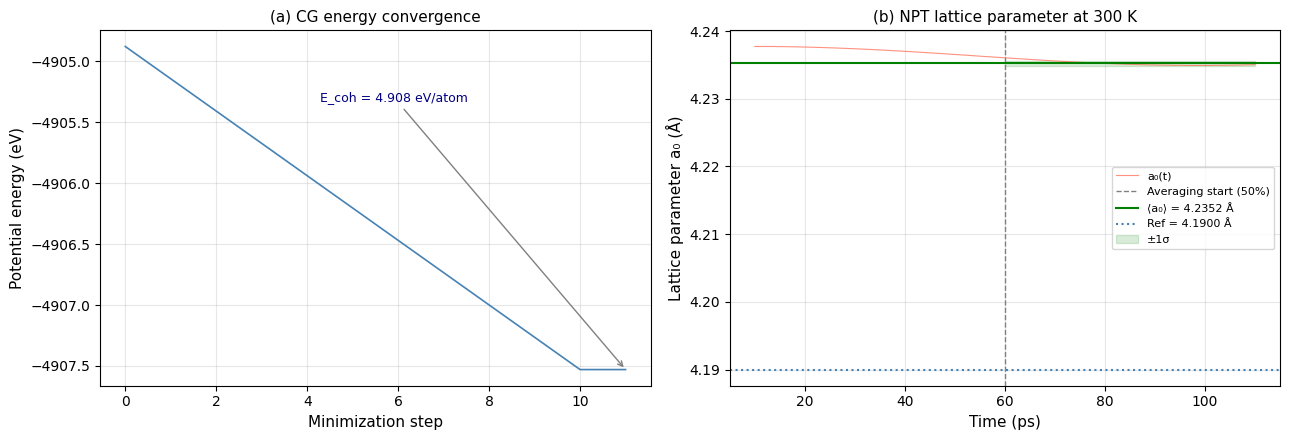

Saved: results/02_bulk_energy_minimization/02_bulk_energy_minimization_NiO_validation.png


In [16]:
# ─────────────────────────────────────────────────────────────
# Plot (a): Energy convergence during minimization
# Plot (b): Lattice parameter vs NPT time
# ─────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# ── (a) Energy convergence ────────────────────────────
ax = axes[0]
if thermo.get('step') and thermo.get('pe'):
    ax.plot(thermo['step'], thermo['pe'], 'steelblue', lw=1.2)
    ax.set_xlabel('Minimization step', fontsize=11)
    ax.set_ylabel('Potential energy (eV)', fontsize=11)
    ax.set_title('(a) CG energy convergence', fontsize=11)
    ax.grid(True, alpha=0.3)
    if E_coh is not None:
        ax.annotate(
            f'E_coh = {E_coh:.3f} eV/atom',
            xy=(thermo['step'][-1], thermo['pe'][-1]),
            xytext=(0.4, 0.8), textcoords='axes fraction',
            arrowprops=dict(arrowstyle='->', color='gray'),
            fontsize=9, color='navy'
        )
else:
    ax.text(0.5, 0.5, 'Run minimization first\n(cell 3.4)',
            ha='center', va='center', transform=ax.transAxes, fontsize=11,
            color='gray')

# ── (b) Lattice parameter vs time ─────────────────────
ax = axes[1]
if os.path.exists(NPT_DUMP):
    ax.plot(time_ps, a0_t, 'tomato', lw=0.8, alpha=0.7, label='a₀(t)')
    ax.axvline(time_ps[half], color='gray', ls='--', lw=1, label='Averaging start (50%)')
    ax.axhline(a0_avg, color='green', lw=1.5, label=f'⟨a₀⟩ = {a0_avg:.4f} Å')
    ax.axhline(A0_REF, color='steelblue', ls=':', lw=1.5, label=f'Ref = {A0_REF:.4f} Å')
    ax.fill_between(time_ps[half:], a0_avg - a0_std, a0_avg + a0_std,
                    color='green', alpha=0.15, label='±1σ')
    ax.set_xlabel('Time (ps)', fontsize=11)
    ax.set_ylabel('Lattice parameter a₀ (Å)', fontsize=11)
    ax.set_title(f'(b) NPT lattice parameter at {TARGET_T} K', fontsize=11)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
else:
    ax.text(0.5, 0.5, 'Run NPT first\n(cell 3.8)',
            ha='center', va='center', transform=ax.transAxes, fontsize=11,
            color='gray')

plt.tight_layout()
plt.savefig('results/02_bulk_energy_minimization/02_bulk_energy_minimization_NiO_validation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: results/02_bulk_energy_minimization/02_bulk_energy_minimization_NiO_validation.png')